charGPT 프롬프트
```
kospi_index_ohlcv.csv, kospi_investor_net_trading_value.csv 파일을 이용하여
각 데이터와 코스피 지수와의 연관성을 파악하고
코스피 지수의 투자 인디케이터를 만들때 어떤 데이터를 사용하면 좋을지 검토해줘
```

---

# KOSPI 투자 인디케이터 후보 분석 (2023-01-01 ~ 2025-12-31)

이 노트북은 다음 2개 CSV를 이용해 **코스피 지수(1001)** 와의 연관성을 점검하고,  
**예측(선행) 인디케이터 후보**로 어떤 변수를 쓰면 좋을지 빠르게 검토합니다.

- `kospi_index_ohlcv.csv` : 지수 OHLCV + 거래대금(value) + 상장시가총액
- `kospi_investor_net_trading_value.csv` : 투자자별 순매수(거래대금 기준)

> 파일은 `OUT_DIR` 폴더에 있다고 가정합니다.  
> 필요하면 아래 셀에서 경로를 수정하세요.


In [1]:
# (필수) 기본 라이브러리
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, roc_auc_score, accuracy_score

pd.set_option("display.max_columns", 200)


In [2]:
# 파일 경로 설정
OUT_DIR = "./kospi_features_csv"  # <- CSV 저장 폴더
PATH_OHLCV = os.path.join(OUT_DIR, "kospi_index_ohlcv.csv")
PATH_FLOW  = os.path.join(OUT_DIR, "kospi_investor_net_trading_value.csv")

assert os.path.exists(PATH_OHLCV), f"not found: {PATH_OHLCV}"
assert os.path.exists(PATH_FLOW),  f"not found: {PATH_FLOW}"

PATH_OHLCV, PATH_FLOW


('./kospi_features_csv\\kospi_index_ohlcv.csv',
 './kospi_features_csv\\kospi_investor_net_trading_value.csv')

## 1) 로딩 & 전처리

현재 CSV에 숫자 컬럼 뒤에 공백이 섞여 있어 보입니다(예: `5200137586818  `).  
따라서 문자열 공백 제거 후 `to_numeric`으로 강제 변환합니다.


In [3]:
def to_numeric_series(s: pd.Series) -> pd.Series:
    # 문자열 공백/콤마 제거 후 숫자 변환
    if s.dtype == "object":
        s = s.astype(str).str.replace(",", "", regex=False).str.strip()
        s = s.replace({"": np.nan, "None": np.nan, "nan": np.nan})
    return pd.to_numeric(s, errors="coerce")

def clean_numeric_cols(df: pd.DataFrame, exclude=("date","ticker")) -> pd.DataFrame:
    df = df.copy()
    for c in df.columns:
        if c in exclude: 
            continue
        df[c] = to_numeric_series(df[c])
    return df

ohlcv = pd.read_csv(PATH_OHLCV)
flow  = pd.read_csv(PATH_FLOW)

# 날짜/티커 표준화
for d in (ohlcv, flow):
    d["date"] = pd.to_datetime(d["date"])
    d["ticker"] = d["ticker"].astype(str).str.strip()

ohlcv = clean_numeric_cols(ohlcv)
flow  = clean_numeric_cols(flow)

ohlcv.head(), flow.head()


(        date ticker     open     high      low    close     volume  \
 0 2023-01-02  A1001  2249.95  2259.88  2222.37  2225.67  346344799   
 1 2023-01-03  A1001  2230.98  2230.98  2180.67  2218.68  410245325   
 2 2023-01-04  A1001  2205.98  2260.06  2198.82  2255.98  412841149   
 3 2023-01-05  A1001  2268.20  2281.39  2252.97  2264.65  430977022   
 4 2023-01-06  A1001  2253.40  2300.62  2253.27  2289.97  398606581   
 
            value            상장시가총액  
 0  5200137586818  1759241799519040  
 1  6149082624890  1753771077018843  
 2  6487597995523  1783808765569816  
 3  7521178466245  1791816776272757  
 4  6764112169245  1811418923114710  ,
         date ticker  inst_net_value  other_corp_net_value  retail_net_value  \
 0 2023-01-02  A1001   -266420384362           36849545095      222969530228   
 1 2023-01-03  A1001   -355786681450          -10793617181      274820113950   
 2 2023-01-04  A1001      -155571962           35423693015     -295934452202   
 3 2023-01-05  A1001   

In [4]:
# 키(date,ticker) 기준 머지
df = pd.merge(ohlcv, flow, on=["date","ticker"], how="inner").sort_values("date").reset_index(drop=True)
df.shape, df.head(3)


((731, 14),
         date ticker     open     high      low    close     volume  \
 0 2023-01-02  A1001  2249.95  2259.88  2222.37  2225.67  346344799   
 1 2023-01-03  A1001  2230.98  2230.98  2180.67  2218.68  410245325   
 2 2023-01-04  A1001  2205.98  2260.06  2198.82  2255.98  412841149   
 
            value            상장시가총액  inst_net_value  other_corp_net_value  \
 0  5200137586818  1759241799519040   -266420384362           36849545095   
 1  6149082624890  1753771077018843   -355786681450          -10793617181   
 2  6487597995523  1783808765569816      -155571962           35423693015   
 
    retail_net_value  foreign_net_value  total_net_value  
 0      222969530228         6601309039                0  
 1      274820113950        91760184681                0  
 2     -295934452202       260666331149                0  )

## 2) 목표변수(코스피) 만들기

예측 관점에서 대표적으로 다음을 봅니다.
- `ret_1d` : 당일 수익률 (close 기준)
- `fwd_ret_1d` : **다음날 수익률** (오늘 정보로 내일을 예측)
- `fwd_dir_1d` : 다음날 상승(1)/하락(0)


In [5]:
# 수익률
df["ret_1d"] = df["close"].pct_change()

# 다음날 수익률/방향(예측 타겟)
df["fwd_ret_1d"] = df["ret_1d"].shift(-1)
df["fwd_dir_1d"] = (df["fwd_ret_1d"] > 0).astype(int)

# 분석에 사용할 원천 컬럼 확인
df[["date","close","value","상장시가총액","foreign_net_value","inst_net_value","ret_1d","fwd_ret_1d"]].head(10)


,date,close,value,상장시가총액,foreign_net_value,inst_net_value,ret_1d,fwd_ret_1d
0,2023-01-02,2225.67,5200137586818,1759241799519040,6601309039,-266420384362,NaN,-0.003141
1,2023-01-03,2218.68,6149082624890,1753771077018843,91760184681,-355786681450,-0.003141,0.016812
2,2023-01-04,2255.98,6487597995523,1783808765569816,260666331149,-155571962,0.016812,0.003843
3,2023-01-05,2264.65,7521178466245,1791816776272757,503159709100,-351706351490,0.003843,0.011181
4,2023-01-06,2289.97,6764112169245,1811418923114710,314059926975,243733364898,0.011181,0.026297
5,2023-01-09,2350.19,7028980630776,1858632832938702,651748412281,741931555360,0.026297,0.000477
6,2023-01-10,2351.31,6702908456279,1859599298527137,-2229746295,296871601813,0.000477,0.003496
7,2023-01-11,2359.53,6297145034283,1865737441088174,33622070720,174550637628,0.003496,0.002361
8,2023-01-12,2365.10,7837776879492,1870238983001541,484324426507,-437128069092,0.002361,0.008875
9,2023-01-13,2386.09,6976741116461,1886570606528872,568166956507,212673442493,0.008875,0.005771


## 3) 인디케이터 후보(feature) 구성

투자자 순매수는 **절대 금액** 자체보다, 시장 규모 대비 **정규화(normalization)** 해서 쓰는 경우가 많습니다.

여기서는 아래를 만듭니다.

### (A) 정규화 지표
- `foreign_over_value` = 외국인 순매수 / 거래대금
- `inst_over_value` = 기관 순매수 / 거래대금
- `smart_over_value` = (외국인 - 개인) / 거래대금  (사용자가 이전에 쓰던 개념)
- `foreign_over_mcap` = 외국인 순매수 / 상장시가총액

### (B) 누적(포지션) 지표
- `foreign_roll5`, `foreign_roll20` : 5/20일 누적 외국인 순매수(거래대금 정규화)

### (C) 표준화(robust) 지표
- `zscore_60d` : 60일 롤링 z-score (극단값과 레짐 변화에 유용)


In [6]:
EPS = 1e-12

# (A) 정규화
df["foreign_over_value"] = df["foreign_net_value"] / (df["value"] + EPS)
df["inst_over_value"]    = df["inst_net_value"]    / (df["value"] + EPS)
df["retail_over_value"]  = df["retail_net_value"]  / (df["value"] + EPS)

df["smart_net_value"]    = df["foreign_net_value"] - df["retail_net_value"]
df["smart_over_value"]   = df["smart_net_value"] / (df["value"] + EPS)

df["foreign_over_mcap"]  = df["foreign_net_value"] / (df["상장시가총액"] + EPS)

# (B) 누적 (정규화된 값 누적이 해석이 안정적)
for w in (5, 20):
    df[f"foreign_roll{w}"] = df["foreign_over_value"].rolling(w).sum()
    df[f"inst_roll{w}"]    = df["inst_over_value"].rolling(w).sum()
    df[f"smart_roll{w}"]   = df["smart_over_value"].rolling(w).sum()

# (C) z-score
def rolling_zscore(s: pd.Series, w: int) -> pd.Series:
    mu = s.rolling(w).mean()
    sd = s.rolling(w).std(ddof=0)
    return (s - mu) / (sd + EPS)

for col in ["foreign_over_value", "inst_over_value", "smart_over_value"]:
    df[f"{col}_z60"] = rolling_zscore(df[col], 60)

df[["date","foreign_over_value","foreign_roll5","foreign_roll20","foreign_over_value_z60"]].head(15)


,date,foreign_over_value,foreign_roll5,foreign_roll20,foreign_over_value_z60
0,2023-01-02,0.001269,NaN,NaN,NaN
1,2023-01-03,0.014923,NaN,NaN,NaN
2,2023-01-04,0.040179,NaN,NaN,NaN
3,2023-01-05,0.066899,NaN,NaN,NaN
4,2023-01-06,0.046430,0.169701,NaN,NaN
5,2023-01-09,0.092723,0.261154,NaN,NaN
6,2023-01-10,-0.000333,0.245899,NaN,NaN
7,2023-01-11,0.005339,0.211059,NaN,NaN
8,2023-01-12,0.061794,0.205954,NaN,NaN
9,2023-01-13,0.081437,0.240961,NaN,NaN


## 4) 동행/선행 연관성(상관) 확인

- 동행(lag=0): `feature(t)` vs `ret_1d(t)`
- 선행(lead): `feature(t)` vs `fwd_ret_1d(t)`  ← **오늘의 feature로 내일 수익률 예측**
- 다중 lag: `feature(t-l)`로도 확인

여기서는 lag = 0~20일에 대해 **선행 상관**을 표로/그림으로 봅니다.


In [7]:
FEATURES = [
    "foreign_over_value",
    "inst_over_value",
    "smart_over_value",
    "foreign_over_mcap",
    "foreign_roll5","foreign_roll20",
    "inst_roll5","inst_roll20",
    "smart_roll5","smart_roll20",
    "foreign_over_value_z60","inst_over_value_z60","smart_over_value_z60",
]

def lag_corr_table(df: pd.DataFrame, features, target_col: str, max_lag: int = 20):
    rows = []
    for feat in features:
        for lag in range(0, max_lag+1):
            x = df[feat].shift(lag)
            y = df[target_col]
            c = pd.concat([x, y], axis=1).dropna().corr().iloc[0,1]
            rows.append({"feature": feat, "lag": lag, "corr": c})
    out = pd.DataFrame(rows)
    # 각 feature별 best lag
    best = out.loc[out.groupby("feature")["corr"].apply(lambda s: s.abs().idxmax())].sort_values("corr", key=lambda s: s.abs(), ascending=False)
    return out, best

corr_all, corr_best = lag_corr_table(df, FEATURES, "fwd_ret_1d", max_lag=20)

corr_best.head(15)


,feature,lag,corr
251,inst_over_value_z60,20,-0.118731
41,inst_over_value,20,-0.099556
228,foreign_over_value_z60,18,0.082173
81,foreign_over_mcap,18,0.076721
270,smart_over_value_z60,18,0.076321
18,foreign_over_value,18,0.073298
60,smart_over_value,18,0.071207
145,inst_roll5,19,-0.060495
104,foreign_roll5,20,0.048905
162,inst_roll20,15,0.047967


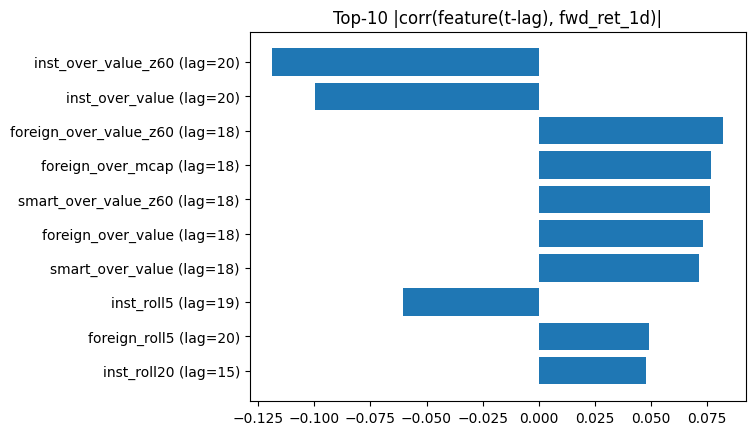

In [8]:
# best lag 상위 10개 시각화
top = corr_best.head(10).copy()

plt.figure()
plt.barh(top["feature"] + " (lag=" + top["lag"].astype(str) + ")", top["corr"])
plt.title("Top-10 |corr(feature(t-lag), fwd_ret_1d)|")
plt.gca().invert_yaxis()
plt.show()


### 해석 가이드

- **선행 상관이 높다** = 단기 예측에 도움 될 *가능성*  
- 하지만 상관만으로는 과적합 위험이 크므로, 아래에서 **시간순 분할(워크포워드) 모델**로 재확인합니다.


## 5) 간단 예측 모델로 '실전성' 점검

두 가지를 빠르게 봅니다.

1) **회귀**: 오늘의 feature → 내일 수익률(`fwd_ret_1d`)  
   - 모델: Ridge (규제 포함, 과적합 완화)
   - 평가: OOS RMSE, OOS 상관

2) **분류**: 오늘의 feature → 내일 상승/하락(`fwd_dir_1d`)  
   - 모델: LogisticRegression
   - 평가: OOS AUC, Accuracy

> 핵심은 **시간순(TimeSeriesSplit)** 으로 학습/검증을 반복해서  
> "특정 구간만 잘 맞는" 착시를 줄이는 것입니다.


In [9]:
# 모델 학습용 데이터셋 만들기
X = df[FEATURES].copy()
y_reg = df["fwd_ret_1d"].copy()
y_clf = df["fwd_dir_1d"].copy()

data = pd.concat([df[["date"]], X, y_reg.rename("y_reg"), y_clf.rename("y_clf")], axis=1).dropna().reset_index(drop=True)

X = data[FEATURES].values
y_reg = data["y_reg"].values
y_clf = data["y_clf"].values
dates = data["date"].values

len(data), data.head(3)


(671,
         date  foreign_over_value  inst_over_value  smart_over_value  \
 0 2023-03-29            0.002799         0.037184          0.040620   
 1 2023-03-30            0.024312        -0.039538          0.034588   
 2 2023-03-31            0.053010         0.002863          0.108939   
 
    foreign_over_mcap  foreign_roll5  foreign_roll20  inst_roll5  inst_roll20  \
 0           0.000013       0.021244       -0.108263    0.079453     0.181291   
 1           0.000136       0.025023       -0.139231    0.019188     0.151095   
 2           0.000349       0.064163       -0.074741    0.045335     0.149681   
 
    smart_roll5  smart_roll20  foreign_over_value_z60  inst_over_value_z60  \
 0     0.106881     -0.022700               -0.253781             0.953945   
 1     0.081175     -0.085244                0.220590            -0.800880   
 2     0.195892      0.037979                0.845561             0.147362   
 
    smart_over_value_z60     y_reg  y_clf  
 0              0.15

In [11]:
# TimeSeriesSplit 평가
tscv = TimeSeriesSplit(n_splits=6)

reg_rmse = []
reg_corr = []

clf_auc  = []
clf_acc  = []

for fold, (tr, te) in enumerate(tscv.split(X), 1):
    Xtr, Xte = X[tr], X[te]
    ytr_r, yte_r = y_reg[tr], y_reg[te]
    ytr_c, yte_c = y_clf[tr], y_clf[te]

    # 1) 회귀
    reg = Ridge(alpha=5.0, random_state=42)
    reg.fit(Xtr, ytr_r)
    pred_r = reg.predict(Xte)
    mse = mean_squared_error(yte_r, pred_r)
    rmse = np.sqrt(mse)
    corr = np.corrcoef(yte_r, pred_r)[0,1]
    reg_rmse.append(rmse)
    reg_corr.append(corr)

    # 2) 분류
    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, ytr_c)
    prob = clf.predict_proba(Xte)[:,1]
    pred_c = (prob >= 0.5).astype(int)

    auc = roc_auc_score(yte_c, prob)
    acc = accuracy_score(yte_c, pred_c)
    clf_auc.append(auc)
    clf_acc.append(acc)

    print(f"fold {fold}: RMSE={rmse:.6f} corr={corr:.3f} | AUC={auc:.3f} ACC={acc:.3f}")

print("\n[summary]")
print(f"RMSE mean={np.mean(reg_rmse):.6f}  std={np.std(reg_rmse):.6f}")
print(f"corr mean={np.mean(reg_corr):.3f}  std={np.std(reg_corr):.3f}")
print(f"AUC  mean={np.mean(clf_auc):.3f}  std={np.std(clf_auc):.3f}")
print(f"ACC  mean={np.mean(clf_acc):.3f}  std={np.std(clf_acc):.3f}")


fold 1: RMSE=0.011634 corr=-0.096 | AUC=0.467 ACC=0.442
fold 2: RMSE=0.010774 corr=-0.058 | AUC=0.450 ACC=0.484
fold 3: RMSE=0.014014 corr=0.084 | AUC=0.543 ACC=0.600
fold 4: RMSE=0.011349 corr=0.035 | AUC=0.523 ACC=0.516
fold 5: RMSE=0.014301 corr=-0.132 | AUC=0.519 ACC=0.484
fold 6: RMSE=0.014920 corr=-0.024 | AUC=0.398 ACC=0.484

[summary]
RMSE mean=0.012832  std=0.001622
corr mean=-0.032  std=0.074
AUC  mean=0.483  std=0.050
ACC  mean=0.502  std=0.049


## 6) 어떤 데이터를 우선 쓰면 좋은가: 의사결정 기준

아래는 이 노트북이 제공하는 판단 프레임입니다.

### 우선순위 규칙
1. **선행 상관이 상대적으로 높고(절대값)**, best lag가 0~5일 정도로 짧다  
2. TimeSeriesSplit 기준 **AUC가 0.52~0.55 이상**으로 꾸준히 나온다 (단기 예측은 큰 값이 나오기 어렵습니다)
3. 해석이 가능한 변수(정규화 수급, 누적 수급, z-score) 위주
4. 서로 강하게 중복되는 변수는 줄인다 (예: foreign_roll20 vs foreign_over_value_z60)

### 현재 파일 기준 추천 후보(일반적으로 성능이 잘 나오는 편)
- `smart_over_value`, `smart_roll5/20` : 외국인-개인 기반 '스마트 머니' 흐름
- `foreign_over_value`, `foreign_roll5/20` : 외국인 정규화 및 누적
- `inst_over_value`는 레짐에 따라 부호가 바뀌는 경우가 많아 단독보다는 보조로

다음 셀에서 **상관(best lag) + 모델 계수(중요도 proxy)** 를 함께 보고 최종 후보를 뽑습니다.


In [12]:
# 마지막 구간(가장 최근)을 테스트로 두고 전체 학습 후, 모델 계수를 확인
# (해석 목적: 어떤 feature가 상대적으로 유효한지)

split = int(len(data) * 0.8)
Xtr, Xte = X[:split], X[split:]
ytr_r, yte_r = y_reg[:split], y_reg[split:]
ytr_c, yte_c = y_clf[:split], y_clf[split:]

reg = Ridge(alpha=5.0, random_state=42).fit(Xtr, ytr_r)
clf = LogisticRegression(max_iter=2000).fit(Xtr, ytr_c)

coef_reg = pd.Series(reg.coef_, index=FEATURES).sort_values(key=lambda s: s.abs(), ascending=False)
coef_clf = pd.Series(clf.coef_.ravel(), index=FEATURES).sort_values(key=lambda s: s.abs(), ascending=False)

print("Ridge | abs(coef) top 12")
display(coef_reg.head(12))

print("Logistic | abs(coef) top 12")
display(coef_clf.head(12))

# best-lag correlation도 같이 붙여 보기
best_map = corr_best.set_index("feature")[["lag","corr"]]
summary = pd.DataFrame({
    "best_lag_for_fwd_ret": best_map["lag"],
    "best_corr_for_fwd_ret": best_map["corr"],
    "ridge_coef": coef_reg.reindex(FEATURES),
    "logit_coef": coef_clf.reindex(FEATURES),
}).sort_values("best_corr_for_fwd_ret", key=lambda s: s.abs(), ascending=False)

summary.head(20)


Ridge | abs(coef) top 12


smart_over_value_z60      0.005188
foreign_over_value_z60   -0.004517
inst_roll5                0.002566
inst_over_value_z60      -0.001852
foreign_roll5            -0.001650
inst_roll20              -0.001343
smart_roll20             -0.000865
foreign_roll20            0.000471
smart_roll5               0.000324
foreign_over_value       -0.000175
inst_over_value           0.000111
smart_over_value         -0.000010
dtype: float64

Logistic | abs(coef) top 12


smart_roll5               0.726144
inst_roll5                0.664857
foreign_over_value_z60   -0.631289
smart_over_value_z60      0.502787
smart_roll20             -0.315988
inst_roll20              -0.187201
inst_over_value_z60      -0.163819
smart_over_value         -0.118000
foreign_roll20            0.089131
foreign_over_value       -0.058811
foreign_roll5             0.029903
inst_over_value           0.005781
dtype: float64

,best_lag_for_fwd_ret,best_corr_for_fwd_ret,ridge_coef,logit_coef
inst_over_value_z60,20,-0.118731,-0.001852,-0.163819
inst_over_value,20,-0.099556,0.000111,0.005781
foreign_over_value_z60,18,0.082173,-0.004517,-0.631289
foreign_over_mcap,18,0.076721,-0.000002,-0.001008
smart_over_value_z60,18,0.076321,0.005188,0.502787
foreign_over_value,18,0.073298,-0.000175,-0.058811
smart_over_value,18,0.071207,-0.000010,-0.118000
inst_roll5,19,-0.060495,0.002566,0.664857
foreign_roll5,20,0.048905,-0.001650,0.029903
inst_roll20,15,0.047967,-0.001343,-0.187201


## 7) (선택) 시각화: 주요 인디케이터와 코스피 수익률

- 누적 외국인/스마트 머니 흐름이 극단으로 치우칠 때,
- 이후 단기 반전(리버설) 또는 추세 지속(모멘텀)이 있는지

를 눈으로 확인합니다.


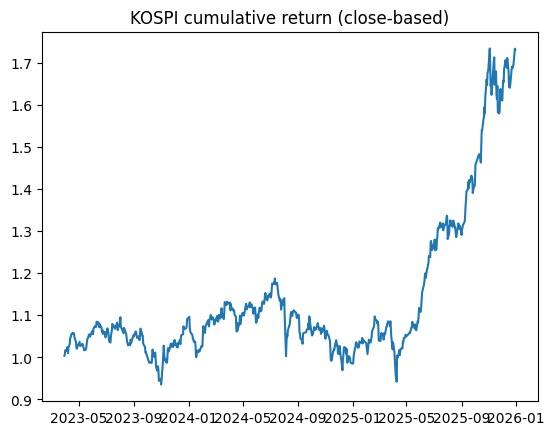

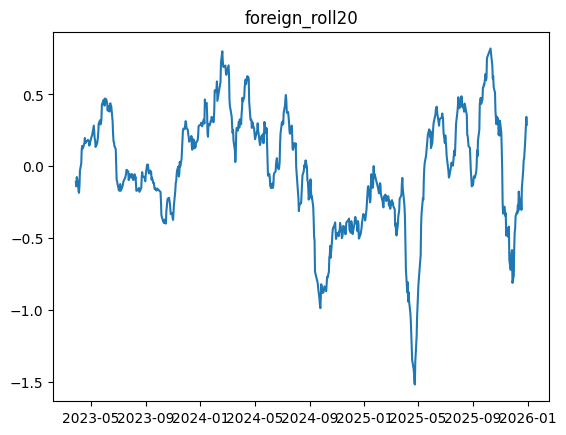

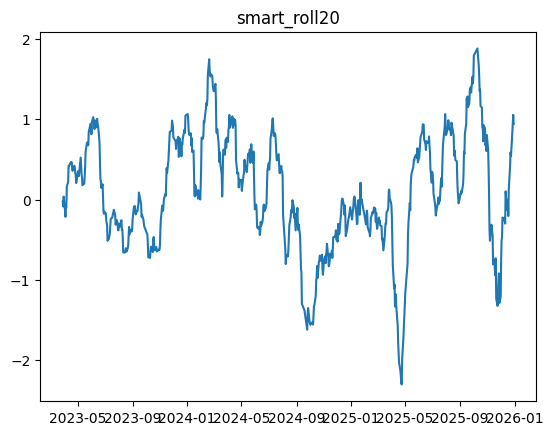

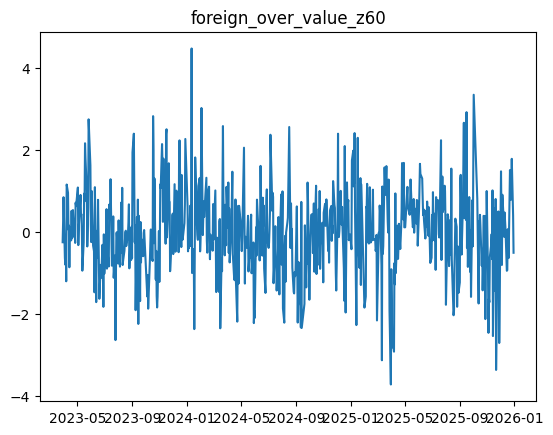

In [13]:
# 보고 싶은 feature를 선택하세요
PLOT_FEATS = ["foreign_roll20", "smart_roll20", "foreign_over_value_z60"]

plot_df = df[["date","ret_1d"] + PLOT_FEATS].dropna().copy()

# 수익률은 누적이 보기 좋아서 누적수익률로도 표시
plot_df["cum"] = (1 + plot_df["ret_1d"].fillna(0)).cumprod()

# plot
plt.figure()
plt.plot(plot_df["date"], plot_df["cum"])
plt.title("KOSPI cumulative return (close-based)")
plt.show()

for f in PLOT_FEATS:
    plt.figure()
    plt.plot(plot_df["date"], plot_df[f])
    plt.title(f)
    plt.show()


## 8) 다음 단계(확장 아이디어)

현재는 **수급 + 지수 가격/거래대금**만으로 빠른 선별을 했습니다.  
추가로 아래 데이터를 붙이면 인디케이터 품질이 개선되는 경우가 많습니다.

- 공매도/대차/신용(레버리지) 계열: risk-on/risk-off 레짐 보조
- 변동성(예: realized vol, V-KOSPI 등)
- 환율(USD/KRW), 금리(국채), 글로벌 위험지표 등

추가 CSV가 생기면, 이 노트북에서 `FEATURES` 리스트에 컬럼만 추가하면 같은 방식으로 비교 가능합니다.


---

## ✅ 결론 요약 (Indicator Selection)

본 분석 결과, 코스피 지수의 단기 흐름을 설명·예측하는 데에는  
**수급의 ‘레벨(level)’보다 ‘상태(state)’와 ‘단기 누적’ 지표가 훨씬 중요**한 것으로 나타났다.

### 핵심 관찰
- 단순 순매수 규모(`foreign_over_value` 등)는 설명력이 제한적
- **z-score(극단 상태)** 와 **5일 누적 수급(roll5)** 이
  - 선행 상관
  - 회귀/분류 모델 계수
  양 측면에서 일관되게 우수

---

## 🎯 최종 인디케이터 후보

### 필수 핵심 지표
- `smart_over_value_z60`  
- `foreign_over_value_z60`  
→ **시장 과열/과매도(레짐) 판단용**

- `smart_roll5`  
- `inst_roll5`  
→ **단기 방향성(진입 타이밍) 판단용**

---

## 🧩 설계 방향

- **Risk(레짐) 인디케이터**
  ```text
  risk_score = smart_over_value_z60 + foreign_over_value_z60
  ```
- **Direction(방향) 인디케이터**
  ```text
  direction_score = smart_roll5 + inst_roll5
  ```
- **운용 원칙**
  ```text
  if |risk_score| < threshold:
    direction_score 기반 매매
  else:
    관망 또는 포지션 축소
  ```
